In [ ]:
# Install any missing libraries (run once)
!pip install plotly kaleido --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

ACCENT   = '#2196F3'   # blue
ACCENT2  = '#FF5722'   # orange
ACCENT3  = '#4CAF50'   # green
print('✅ Libraries loaded')

✅ Libraries loaded


In [4]:
# ⬆️  Please upload 'cleaned_data.csv' to the Colab runtime files (left sidebar -> folder icon -> upload icon)
# then run this cell

# Assuming 'cleaned_data.csv' is now in the root of the Colab environment
df = pd.read_csv('cleaned_data.csv', encoding='latin1')

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape : 17,119 rows × 13 columns
Columns: ['page', 'name', 'description', 'Speciality', 'address', 'fee', 'reviews_count', 'profile_url', 'image_url', 'about_doctor', 'symptoms_text', 'subspecialties_text', 'waiting_time_min']


,page,name,description,Speciality,address,fee,reviews_count,profile_url,image_url,about_doctor,symptoms_text,subspecialties_text,waiting_time_min
0,1,Mohamed Fateen Anous,Consultant of General and Laproscopic Surgery,General Surgery,New Cairo,600,37,https://www.vezeeta.com/en/dr/doctor-mohamed-f...,https://cdn-dr-images.vezeeta.com/Assets/Image...,Consultant of general and laparoscopic surgery,"Pilonidal Cyst, Intestinal Obstruction, Fistul...","Obesity Surgery, Abdominal Surgery, Adult Gast...",26
1,1,Heba Hassan Hadhoud,"Specialist in oral and dental medicine, implan...",Dentistry,El-Rehab,200,608,https://www.vezeeta.com/en/dr/doctor-heba--has...,https://cdn-dr-images.vezeeta.com/Assets/Image...,NaN,"Bruxism, Teeth whitening, TMJ Disorder, Molar ...","Pediatric Dentistry, Cosmetic Dentistry, Endod...",14
2,1,Hoda Beder,"Consultant of Obstetrics, Gynecology and Infer...",Reproductive Medicine & Infertility,Tanta,150,131,https://www.vezeeta.com/en/dr/doctor-hoda-bede...,https://cdn-dr-images.vezeeta.com/Assets/Image...,Dr. Huda Badir\n\n-PhD in Obstetrics and Gynec...,"Vaginal Dryness, Pregnancy, Placental Abruptio...","Gynaecologic Oncological Surgery, Obstetrics, ...",22


In [5]:
# ── 1. Fix waiting_time: -1 means 'not reported' → replace with NaN
df['waiting_time_min'] = df['waiting_time_min'].replace(-1, np.nan)

# ── 2. Fee segment buckets
bins   = [0, 200, 400, 600, 1000, 99999]
labels = ['Budget\n(≤200)', 'Affordable\n(201-400)',
          'Mid\n(401-600)', 'Premium\n(601-1000)', 'Ultra\n(1000+)']
df['fee_segment'] = pd.cut(df['fee'], bins=bins, labels=labels, right=True)

# ── 3. Review tier
def review_tier(n):
    if n == 0:   return '0 — No reviews'
    elif n <= 10: return '1-10'
    elif n <= 50: return '11-50'
    elif n <= 200: return '51-200'
    else:          return '200+'
df['review_tier'] = df['reviews_count'].apply(review_tier)

# ── 4. Area-tier: premium vs mid vs budget areas (based on median fee)
area_median = df.groupby('address')['fee'].median()
df['area_tier'] = df['address'].map(
    lambda a: 'Premium Area' if area_median.get(a, 0) >= 600
    else ('Mid Area' if area_median.get(a, 0) >= 400 else 'Budget Area')
)

print('Nulls after cleaning:')
print(df[['fee','reviews_count','waiting_time_min']].isnull().sum())
print('\n✅ Feature engineering done')

Nulls after cleaning:
fee                    0
reviews_count          0
waiting_time_min    7159
dtype: int64

✅ Feature engineering done


### 💡 Actionable Business Recommendations
Based on the specialty distribution analysis, Vezeeta can take the following actions:
- **Marketing Focus:** Direct marketing and promotional efforts toward these specific specialties.
- **Increase Supply:** Actively onboard more doctors in highly requested specialties to bridge the gap between supply and patient demand.

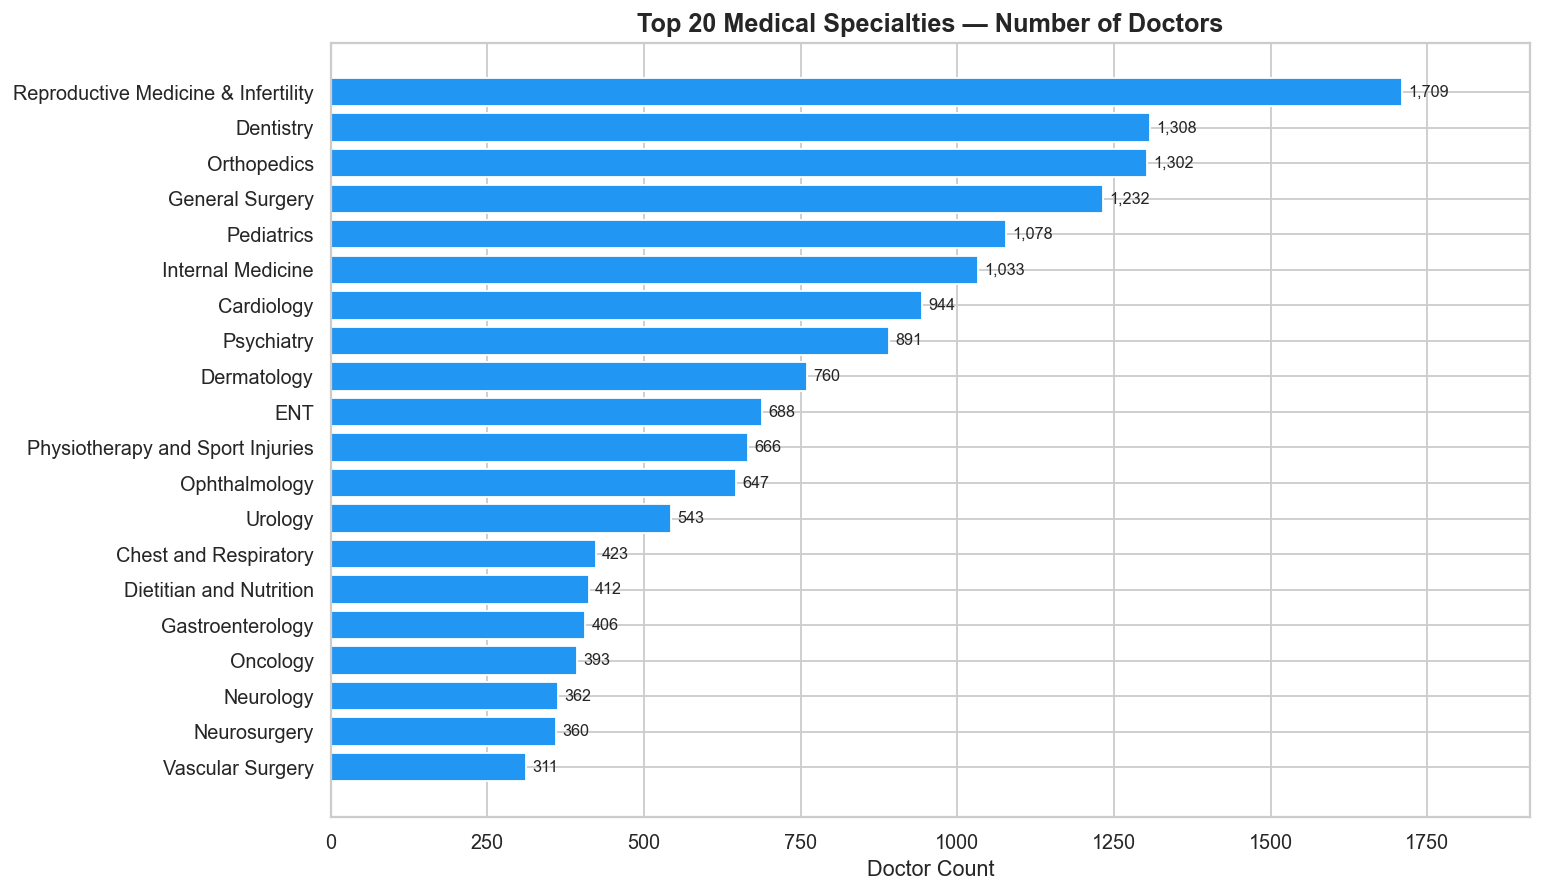


🔍 Insight: Top 3 specialties account for 25.2% of all doctors


In [6]:
## ── 1A. Top 20 Specialties by Doctor Count

top20 = df['Speciality'].value_counts().head(20).reset_index()
top20.columns = ['Speciality', 'count']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top20['Speciality'][::-1], top20['count'][::-1],
               color=ACCENT, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va='center', fontsize=9)
ax.set_title('Top 20 Medical Specialties — Number of Doctors', fontsize=14, fontweight='bold')
ax.set_xlabel('Doctor Count')
ax.set_xlim(0, top20['count'].max() * 1.12)
plt.tight_layout()
plt.show()

print('\n🔍 Insight: Top 3 specialties account for',
      f"{top20.head(3)['count'].sum()/len(df)*100:.1f}% of all doctors")

### 💡 Strategic Insights & Recommendations
- **Investment Opportunities:** Capitalize on underserved niches (specialties with low supply).
- **Physician Acquisition:** Actively attract and onboard more doctors in these specific fields to balance supply and demand.

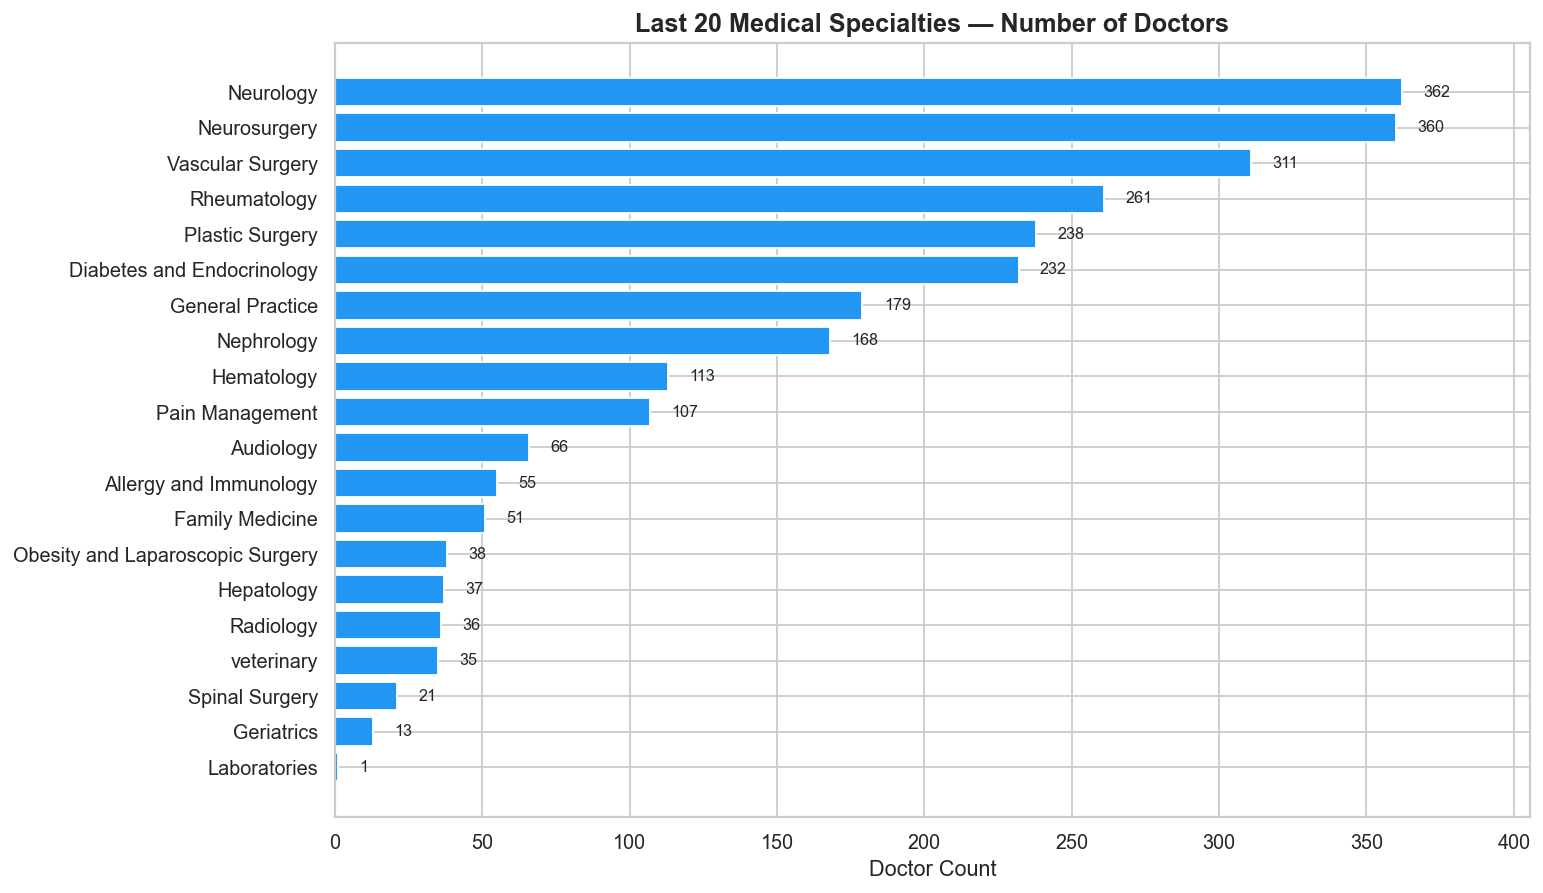


🔍 Insight: Bottom 3 specialties account for 0.2045% of all doctors


In [19]:
## ── 1A. Last 20 Specialties by Doctor Count

# 1. Use .tail(20) to get the bottom 20 specialties
last20 = df['Speciality'].value_counts().tail(20).reset_index()
last20.columns = ['Speciality', 'count']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(last20['Speciality'][::-1], last20['count'][::-1],
               color=ACCENT, edgecolor='white')

# Calculate a dynamic offset for text so it looks good even with very small numbers
text_offset = last20['count'].max() * 0.02 

for bar in bars:
    ax.text(bar.get_width() + text_offset, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va='center', fontsize=9)

# 2. Update Titles and Labels
ax.set_title('Last 20 Medical Specialties — Number of Doctors', fontsize=14, fontweight='bold')
ax.set_xlabel('Doctor Count')
ax.set_xlim(0, last20['count'].max() * 1.12)
plt.tight_layout()
plt.show()

# 3. Update the insight to reflect the bottom 3 specialties
print('\n🔍 Insight: Bottom 3 specialties account for',
      f"{last20.tail(3)['count'].sum()/len(df)*100:.4f}% of all doctors")

## 1. Key Insights: The Supply Gap
-   Extreme Skewness: There is a massive disparity between the most and least populated specialties. The top specialty (Reproductive Medicine, 1,709) has over 1,700x more practitioners than the lowest (Laboratories, 1).

-   Highly Specialized "Scarcity" Fields: Several critical chronic and specialized fields fall into the bottom 20, notably:

    -   Geriatrics (13): Extremely low supply despite aging populations.

    -   Radiology (36): Diagnostic services appear significantly underrepresented.

    -   Family Medicine (51): Surprisingly low for a foundational primary care specialty.

-   High-Volume Surgical Specialties: The "Top 20" list is dominated by elective or high-intervention fields like Dentistry (1,308) and Orthopedics (1,302), suggesting these are the primary revenue drivers for the platform.

-   The "Long Tail" of Specialized Care: The "Last 20" chart shows a rapid decline in numbers, with half of those specialties having fewer than 100 doctors available across the platform.

## 2. Strategic Recommendations
### A. Platform Inventory Management
-   Onboarding Priority: The platform should actively recruit for Geriatrics, Radiology, and Nephrology. These are essential services that likely have high search volume but currently offer users very little choice.

-   General Practice vs. Family Medicine: There is a discrepancy between General Practice (179) and Family Medicine (51). Standardizing these categories or encouraging GPs to certify in Family Medicine could improve the perceived quality of primary care supply.

### B. Commercial & Marketing Strategy
-   Leverage High-Supply Specialties: Since Reproductive Medicine, Dentistry, and Orthopedics have the highest saturation, use these for SEO and "hook" campaigns to bring new users to the platform.

-   Niche Market Development: For specialties like Plastic Surgery (238) or Rheumatology (261)—which are in the bottom 20 but still have a triple-digit count—create targeted landing pages to dominate these specific high-value niche markets.

### C. Product Feature Opportunities
-   Laboratory Integration: With only 1 laboratory listed, this is a significant "dead zone" in the user journey. Developing a separate "Labs & Scans" module rather than treating them as a medical specialty could capture this missing market share.

-   Telehealth Focus: For the "Last 20" specialties where physical access is limited by low doctor counts, promote Telehealth features to allow the few available specialists (like those in Hematology or Immunology) to consult with patients nationwide.

## 3. Proposed Data Science Follow-ups
-   Demand Mapping: Perform a "Supply-Demand Ratio" analysis by comparing these counts against Search Query Volume for each specialty.

-   Conversion Analysis: Check if specialties with low doctor counts have higher "bounce rates" (users leaving the app without booking) due to lack of options or distance.

-   Geographical Heatmaps: Determine if the bottom 20 specialties are concentrated in a single city, which would indicate a total lack of coverage for the rest of the country.

### 📌 What It Means
- **Average Fee by Specialty:** Calculates the average or median consultation fee across different medical fields.

### 💡 Insights
- **Price Variance:** There is a significant gap in pricing among specialties. Some are premium/highly priced (e.g., Psychiatry), while others are significantly more affordable.

### 🧠 Business Value for Vezeeta
- **Provide Pricing Insights:** Share data-driven market pricing trends with healthcare providers.
- **Pricing Assistance:** Help doctors set fair and competitive consultation fees.
- **"Recommended Price" Feature:** Introduce a system that suggests a "Recommended Price" to doctors based on their specialty, experience, and geographic location.

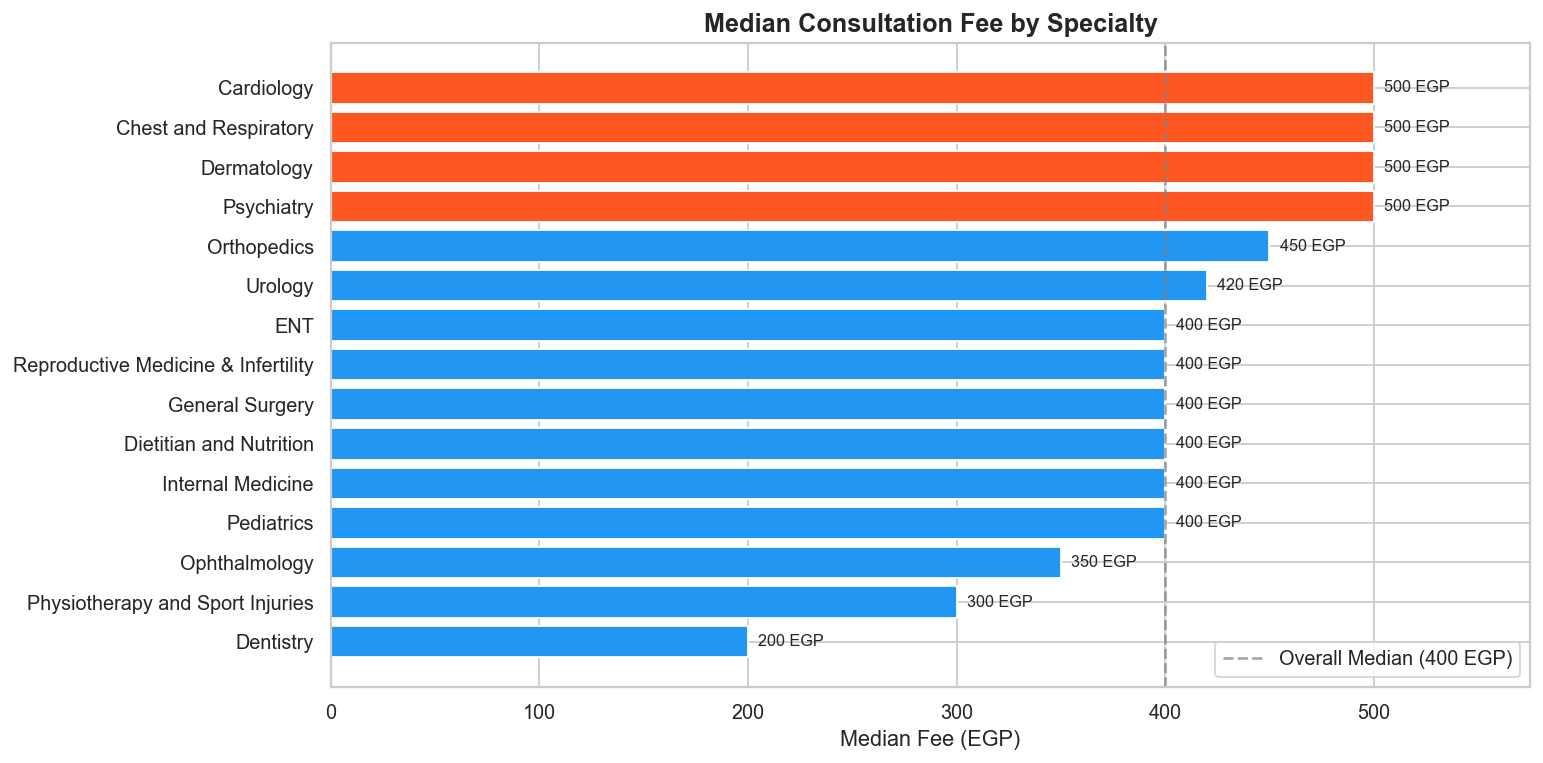


📋 Fee Summary Table:
                         Speciality  median_fee   mean_fee  count
                         Cardiology       500.0 491.672669    944
              Chest and Respiratory       500.0 491.704492    423
                        Dermatology       500.0 485.384211    760
                         Psychiatry       500.0 604.938272    891
                        Orthopedics       450.0 477.786482   1302
                            Urology       420.0 454.952118    543
                                ENT       400.0 444.693314    688
Reproductive Medicine & Infertility       400.0 453.121123   1709
                    General Surgery       400.0 456.784903   1232
            Dietitian and Nutrition       400.0 470.310680    412
                  Internal Medicine       400.0 474.197483   1033
                         Pediatrics       400.0 441.367347   1078
                      Ophthalmology       350.0 414.234930    647
   Physiotherapy and Sport Injuries       300.0 323.10

In [20]:
## ── 1B. Median Fee by Specialty (Top 15)

top15_specs = df['Speciality'].value_counts().head(15).index
fee_by_spec = (
    df[df['Speciality'].isin(top15_specs)]
    .groupby('Speciality')['fee']
    .agg(median_fee='median', mean_fee='mean', count='size')
    .sort_values('median_fee', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [ACCENT2 if f >= 500 else ACCENT for f in fee_by_spec['median_fee']]
bars = ax.barh(fee_by_spec['Speciality'][::-1],
               fee_by_spec['median_fee'][::-1], color=colors[::-1])
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.0f} EGP", va='center', fontsize=9)
ax.axvline(df['fee'].median(), color='gray', linestyle='--', alpha=0.7, label=f'Overall Median ({df["fee"].median():.0f} EGP)')
ax.set_title('Median Consultation Fee by Specialty', fontsize=14, fontweight='bold')
ax.set_xlabel('Median Fee (EGP)')
ax.legend()
ax.set_xlim(0, fee_by_spec['median_fee'].max() * 1.15)
plt.tight_layout()
plt.show()

print('\n📋 Fee Summary Table:')
print(fee_by_spec[['Speciality','median_fee','mean_fee','count']].to_string(index=False))

## Financial Analysis: Median Consultation Fees by Specialty
### 1. Executive Summary
This visualization highlights the pricing structure across the top medical specialties on the platform. By analyzing the Median Consultation Fee (EGP), we can identify premium services, standard market rates, and pricing anomalies that impact platform revenue and patient accessibility.

### 2. Key Insights
#### The Premium Tier (High-Value)
-   Price Leaders: Cardiology, Chest & Respiratory, Dermatology, and Psychiatry command the highest median fee at 500 EGP.

-   Market Positioning: These specialties are priced 25% higher than the overall platform median (400 EGP), suggesting they are viewed as "high-value" or "specialized" services by the market.

#### The Standard Tier (Market Median)
-   Clustering at the Median: A large majority of core specialties—including General Surgery, Internal Medicine, Pediatrics, and Reproductive Medicine—are perfectly aligned with the Overall Median of 400 EGP.

-   Price Consistency: This suggests a strong market consensus on what a "standard" specialist consultation should cost in Egypt.

#### The Entry Tier (Affordable Care)
-   Volume vs. Price: Dentistry has the lowest median fee at 200 EGP, followed by Physiotherapy at 300 EGP.

-   Strategic Note: In the previous "Number of Doctors" analysis, Dentistry was one of the most populated specialties. The low median fee combined with high supply indicates an extremely competitive, high-volume, low-margin market.

### 3. Strategic Recommendations
#### Pricing & Revenue Optimization
-   Premium Upselling: Since Psychiatry and Dermatology are already in the premium bracket, the platform could introduce "Elite" or "Consultant" tiers for these specific fields to capture even higher-end market segments.

-   Addressing the Dentistry Gap: With Dentistry priced at 50% of the premium specialties, the platform should focus on volume-based incentives (e.g., membership plans or loyalty points) to maximize revenue from this high-traffic but low-cost segment.

#### Marketing & User Acquisition
-   Affordability Campaigns: Use Dentistry and Physiotherapy in marketing campaigns targeted at price-sensitive users. These serve as "entry points" to get users onto the platform.

-   Specialized Bundles: Create packages for Chest & Respiratory or Cardiology (the 500 EGP tier) that include follow-ups, as these higher prices may deter some users from completing a full treatment cycle.

#### Competitive Balancing
-   Fee Sensitivity: If Ophthalmology (350 EGP) or ENT (400 EGP) sees a sudden drop in bookings, it may be because they are priced too close to the premium 500 EGP tier without offering the same perceived specialized value. Monitoring the Price-to-Booking ratio for these mid-tier specialties is critical.

### 🟢 1C — Box Plot: Fee Distribution by Specialty

📌 **What It Means:**
- Visualizes the distribution of consultation fees, highlighting key statistical metrics: minimum, maximum, median, and outliers.

💡 **Insight:**
- **High Price Variability:** Certain specialties, such as Psychiatry, exhibit a significant spread in pricing, indicating a lack of standardized fees in that field.

🧠 **Business Value for Vezeeta:**
- **Understand Price Spreads:** Gain clear visibility into the standard pricing ranges for each medical specialty.
- **Identify Abnormal Pricing (Anomaly Detection):** Detect outlier fees (doctors charging significantly higher or lower than the market average) to ensure fair pricing and maintain platform quality control.

In [8]:
## ── 1C. Box Plot — Fee Distribution per Specialty

spec_order = fee_by_spec['Speciality'].tolist()  # sorted by median
plot_df = df[df['Speciality'].isin(top15_specs)].copy()

fig = px.box(
    plot_df, x='fee', y='Speciality',
    category_orders={'Speciality': spec_order},
    title='Fee Distribution by Specialty (Box Plot)',
    labels={'fee': 'Fee (EGP)', 'Speciality': ''},
    color='Speciality',
    points=False,
    height=600
)
fig.update_layout(showlegend=False)
fig.show()

print('\n💡 Recommendation: Psychiatry has the highest fee variability — high earning potential but also outliers.')


💡 Recommendation: Psychiatry has the highest fee variability — high earning potential but also outliers.


---
#  Phase 2 — Geographic Analysis
> **Questions:** Where are doctors concentrated? Which areas are premium? Which are underserved?

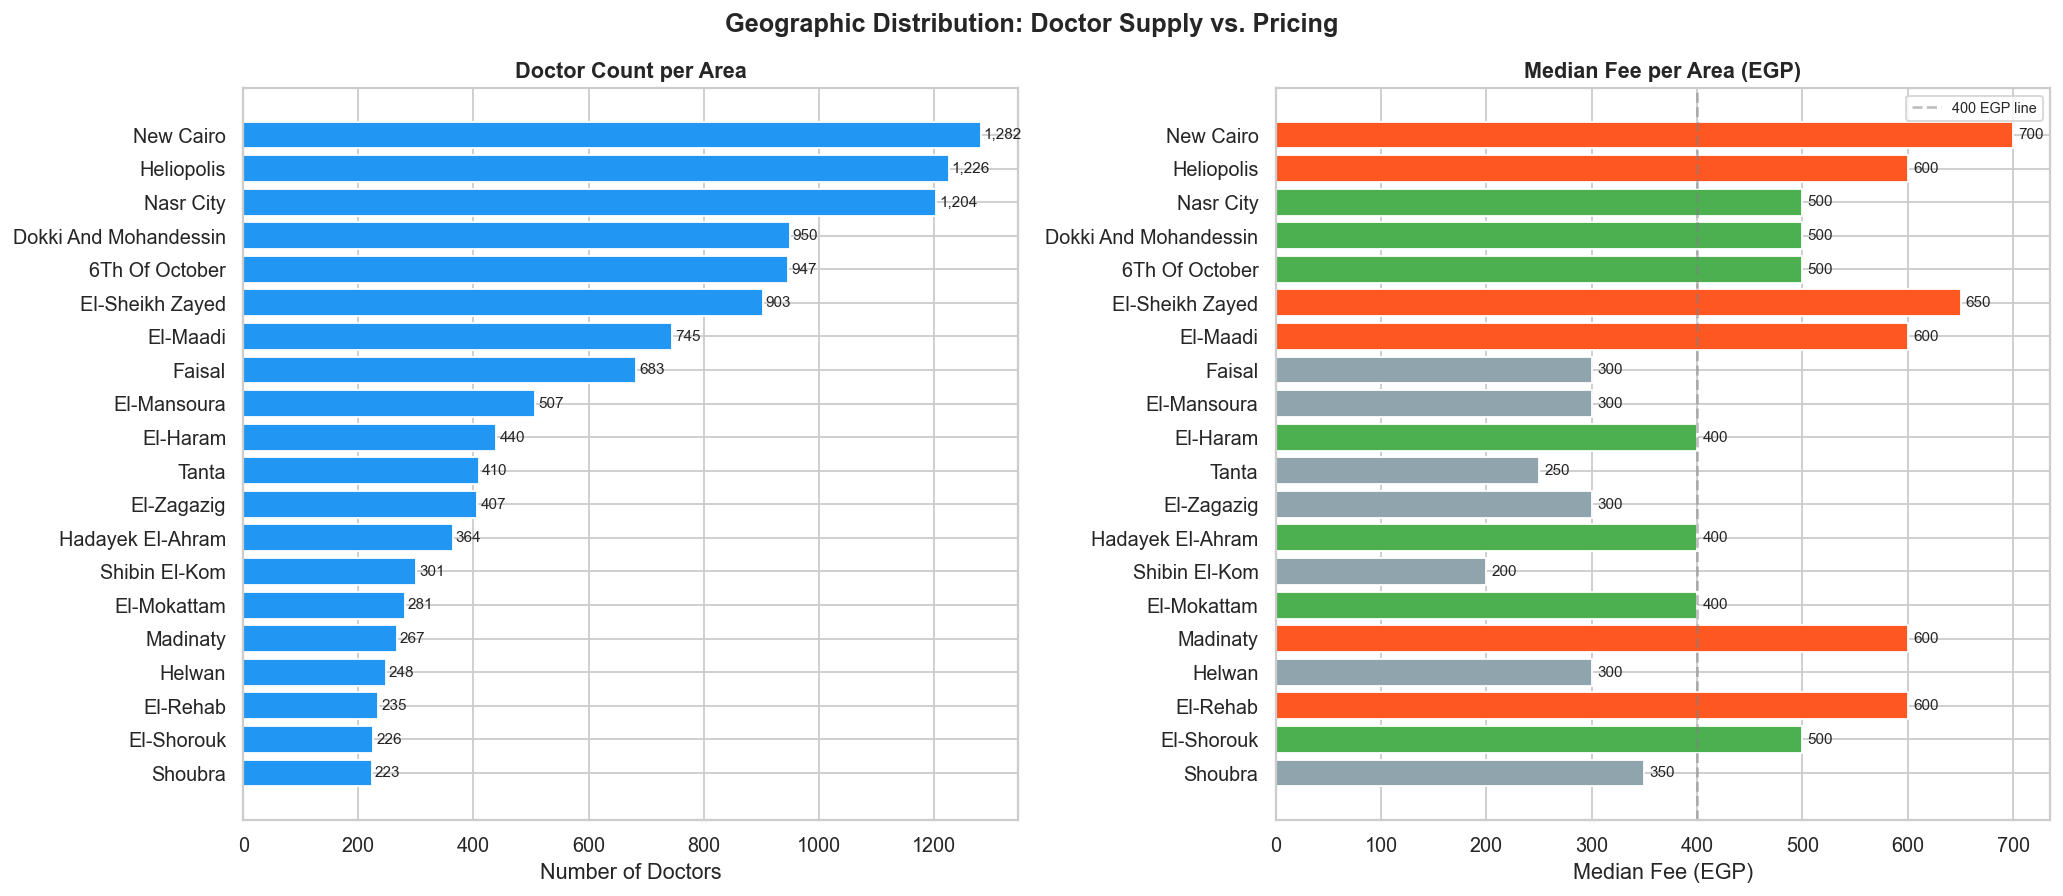

In [9]:
## ── 2A. Doctor Count per Area (Top 20)

area_stats = (
    df.groupby('address')
    .agg(doctor_count=('name','count'),
         median_fee=('fee','median'),
         avg_reviews=('reviews_count','mean'))
    .sort_values('doctor_count', ascending=False)
    .head(20)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: doctor count
ax1 = axes[0]
bars = ax1.barh(area_stats['address'][::-1], area_stats['doctor_count'][::-1],
                color=ACCENT)
for bar in bars:
    ax1.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():,.0f}", va='center', fontsize=8.5)
ax1.set_title('Doctor Count per Area', fontweight='bold')
ax1.set_xlabel('Number of Doctors')

# Right: median fee
ax2 = axes[1]
colors2 = [ACCENT2 if f >= 600 else (ACCENT3 if f >= 400 else '#90A4AE')
           for f in area_stats['median_fee'][::-1]]
bars2 = ax2.barh(area_stats['address'][::-1], area_stats['median_fee'][::-1],
                 color=colors2)
for bar in bars2:
    ax2.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():.0f}", va='center', fontsize=8.5)
ax2.set_title('Median Fee per Area (EGP)', fontweight='bold')
ax2.set_xlabel('Median Fee (EGP)')
ax2.axvline(400, color='gray', linestyle='--', alpha=0.5, label='400 EGP line')
ax2.legend(fontsize=8)

plt.suptitle('Geographic Distribution: Doctor Supply vs. Pricing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

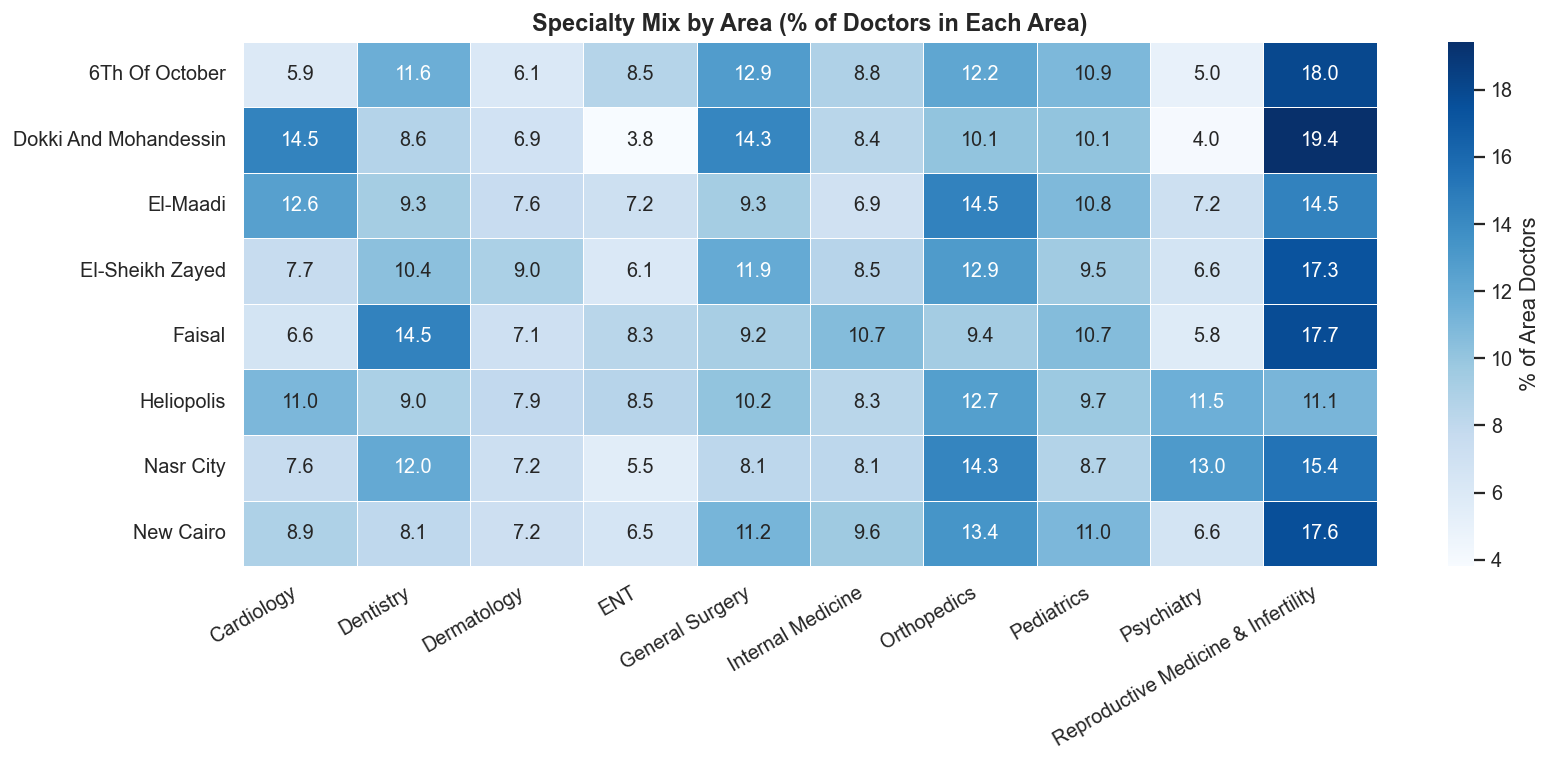


💡 Insight: Darker cells = higher concentration of that specialty in the area.


In [10]:
## ── 2B. Specialty Mix by Top Areas (Heatmap)

top8_areas = df['address'].value_counts().head(8).index
top8_specs = df['Speciality'].value_counts().head(10).index

heatmap_df = (
    df[df['address'].isin(top8_areas) & df['Speciality'].isin(top8_specs)]
    .groupby(['address','Speciality'])['name']
    .count()
    .unstack(fill_value=0)
)
# Normalize per area (% of that area's doctors)
heatmap_pct = heatmap_df.div(heatmap_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Area Doctors'})
ax.set_title('Specialty Mix by Area (% of Doctors in Each Area)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\n💡 Insight: Darker cells = higher concentration of that specialty in the area.')

In [11]:
## ── 2C. Supply vs. Fee Bubble Chart

area_bubble = (
    df.groupby('address')
    .agg(doctor_count=('name','count'),
         median_fee=('fee','median'),
         avg_waiting=('waiting_time_min','mean'))
    .reset_index()
)
area_bubble = area_bubble[area_bubble['doctor_count'] >= 50]

fig = px.scatter(
    area_bubble,
    x='doctor_count', y='median_fee',
    size='doctor_count', color='median_fee',
    text='address',
    color_continuous_scale='RdYlGn_r',
    title='Doctor Supply vs. Median Fee per Area',
    labels={'doctor_count': 'Number of Doctors', 'median_fee': 'Median Fee (EGP)'},
    height=550
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.show()

print('\n💡 Insight: Areas top-right = high fee + high supply (premium, competitive markets).')
print('           Areas bottom-left = low fee + low supply (potential underserved markets).')


💡 Insight: Areas top-right = high fee + high supply (premium, competitive markets).
           Areas bottom-left = low fee + low supply (potential underserved markets).


---
#  Phase 3 — Price / Fee Segmentation
> **Questions:** How is the market segmented? Who prices premium? Is there a sweet spot?

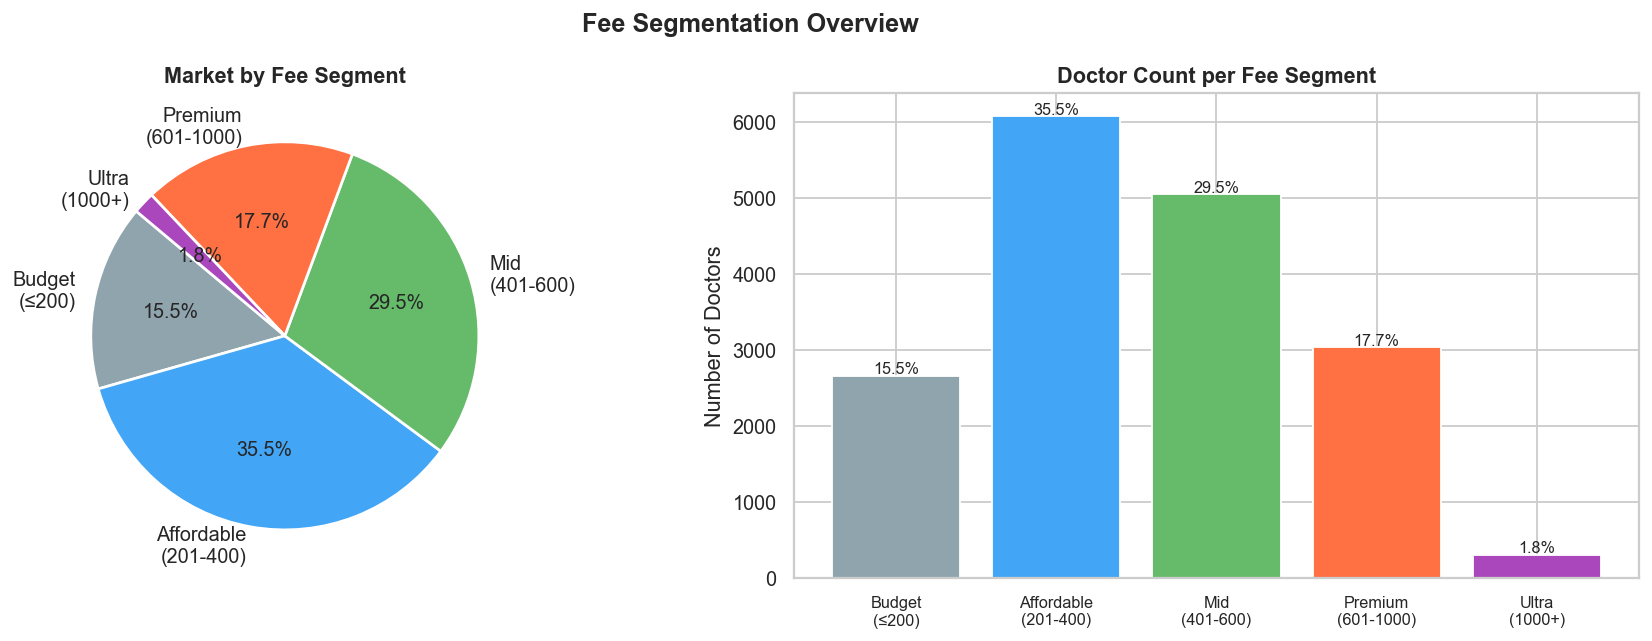


📊 Summary:
              segment  count       pct
       Budget\n(≤200)   2657 15.520766
Affordable\n(201-400)   6069 35.451837
       Mid\n(401-600)   5045 29.470179
  Premium\n(601-1000)   3035 17.728839
       Ultra\n(1000+)    312  1.822536


In [12]:
## ── 3A. Fee Segment Distribution

seg_counts = df['fee_segment'].value_counts().sort_index().reset_index()
seg_counts.columns = ['segment', 'count']
seg_counts['pct'] = seg_counts['count'] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie
palette = ['#90A4AE','#42A5F5','#66BB6A','#FF7043','#AB47BC']
axes[0].pie(seg_counts['count'], labels=seg_counts['segment'],
            autopct='%1.1f%%', colors=palette, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Market by Fee Segment', fontweight='bold')

# Bar
bars = axes[1].bar(range(len(seg_counts)), seg_counts['count'],
                   color=palette, edgecolor='white')
axes[1].set_xticks(range(len(seg_counts)))
axes[1].set_xticklabels(seg_counts['segment'], fontsize=9)
axes[1].set_ylabel('Number of Doctors')
axes[1].set_title('Doctor Count per Fee Segment', fontweight='bold')
for bar, pct in zip(bars, seg_counts['pct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{pct:.1f}%', ha='center', fontsize=9)

plt.suptitle('Fee Segmentation Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Summary:')
print(seg_counts.to_string(index=False))

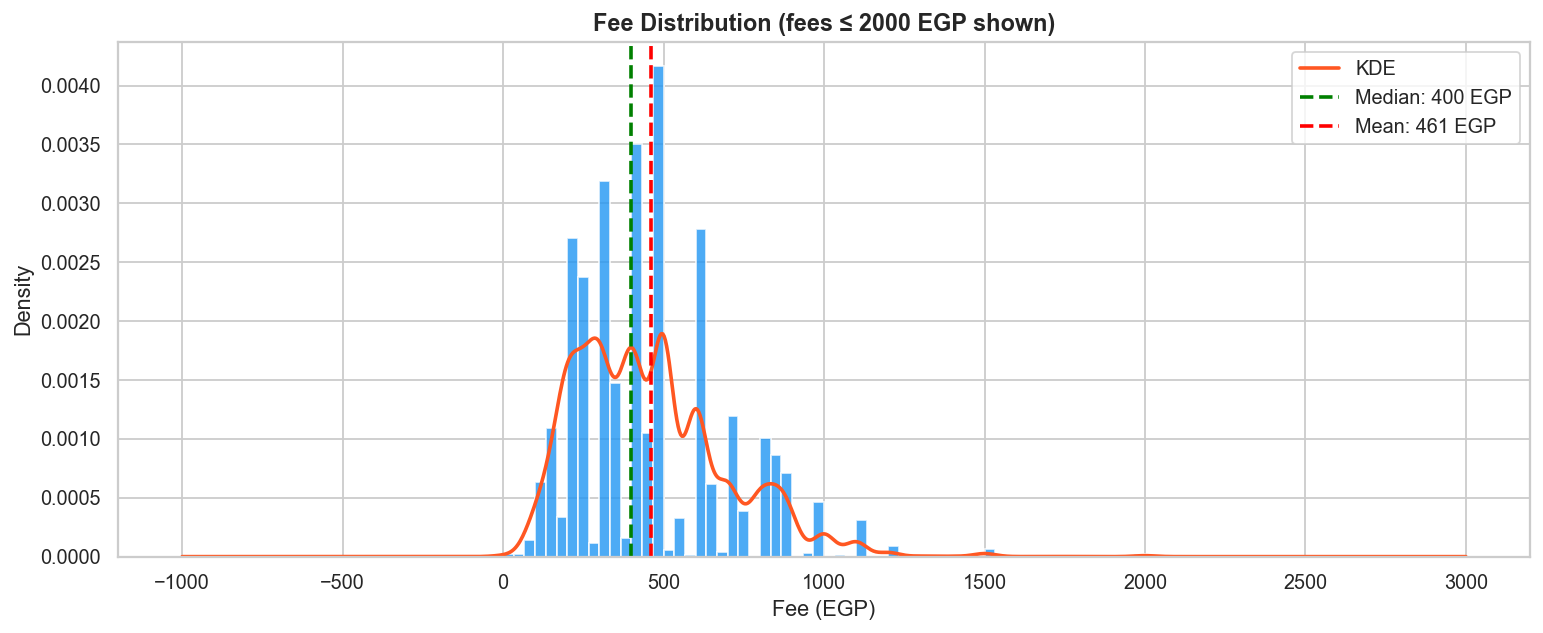


Overall Fee Stats:
  Median : 400 EGP
  Mean   : 461 EGP
  Std Dev: 264 EGP
  75th % : 600 EGP
  90th % : 800 EGP


In [13]:
## ── 3B. Fee Distribution — Histogram + KDE

fee_clean = df[df['fee'] <= 2000]['fee']  # remove extreme outliers for viz

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(fee_clean, bins=60, color=ACCENT, edgecolor='white', alpha=0.8, density=True)
fee_clean.plot.kde(ax=ax, color=ACCENT2, linewidth=2, label='KDE')
ax.axvline(df['fee'].median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {df["fee"].median():.0f} EGP')
ax.axvline(df['fee'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {df["fee"].mean():.0f} EGP')
ax.set_title('Fee Distribution (fees ≤ 2000 EGP shown)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fee (EGP)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nOverall Fee Stats:')
print(f"  Median : {df['fee'].median():.0f} EGP")
print(f"  Mean   : {df['fee'].mean():.0f} EGP")
print(f"  Std Dev: {df['fee'].std():.0f} EGP")
print(f"  75th % : {df['fee'].quantile(0.75):.0f} EGP")
print(f"  90th % : {df['fee'].quantile(0.90):.0f} EGP")

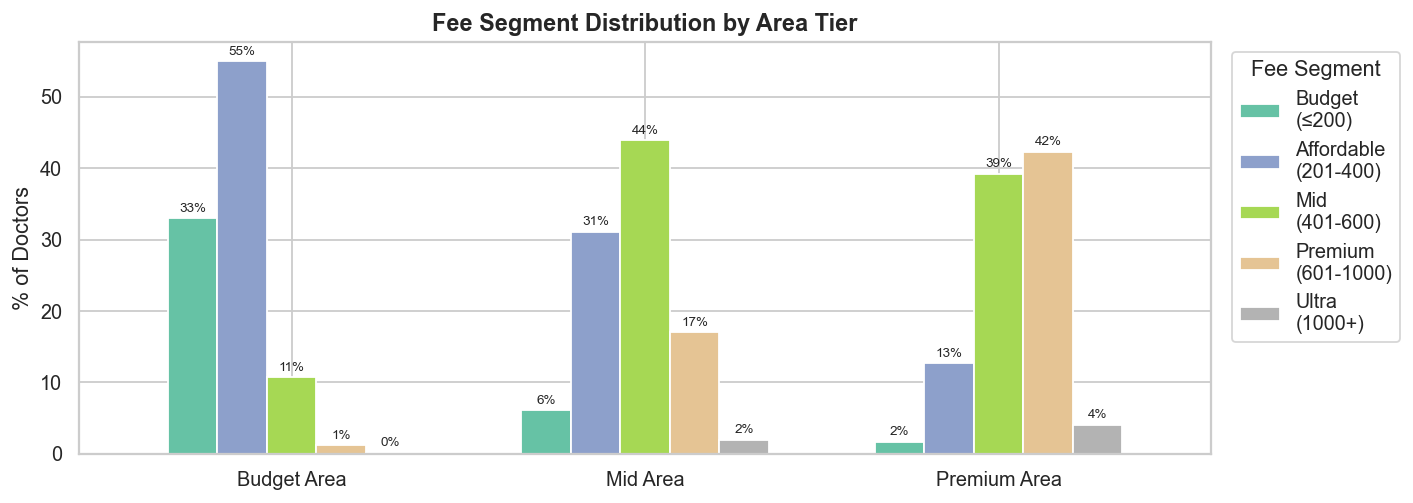


💡 Insight: Premium areas have a much higher share of Mid/Premium fee doctors.


In [14]:
## ── 3C. Fee Segment × Area Tier Cross-Tab

cross = pd.crosstab(df['area_tier'], df['fee_segment'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(11, 4))
cross.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
ax.set_title('Fee Segment Distribution by Area Tier', fontsize=13, fontweight='bold')
ax.set_ylabel('% of Doctors')
ax.set_xlabel('')
ax.legend(title='Fee Segment', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=7.5, padding=2)
plt.tight_layout()
plt.show()

print('\n💡 Insight: Premium areas have a much higher share of Mid/Premium fee doctors.')

---
#  Phase 4 — Doctor Performance
> **Questions:** Who are the top-reviewed doctors? Does high fee = more reviews? What's the waiting time picture?

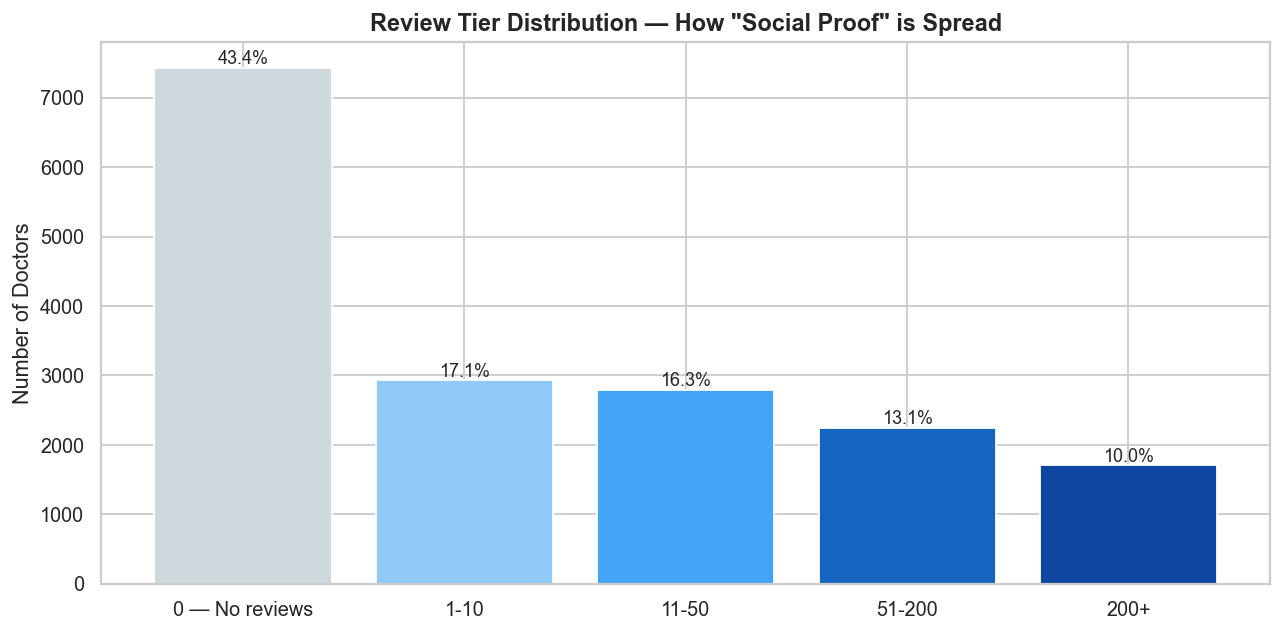


🔍 43.4% of doctors have ZERO reviews — massive cold-start opportunity.


In [15]:
## ── 4A. Review Tier Distribution

tier_order = ['0 — No reviews','1-10','11-50','51-200','200+']
rev_dist = df['review_tier'].value_counts().reindex(tier_order).reset_index()
rev_dist.columns = ['tier', 'count']
rev_dist['pct'] = rev_dist['count'] / len(df) * 100

palette2 = ['#CFD8DC','#90CAF9','#42A5F5','#1565C0','#0D47A1']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(rev_dist['tier'], rev_dist['count'], color=palette2, edgecolor='white')
for bar, pct in zip(bars, rev_dist['pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{pct:.1f}%', ha='center', fontsize=10)
ax.set_title('Review Tier Distribution — How "Social Proof" is Spread', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Doctors')
plt.tight_layout()
plt.show()

print(f"\n🔍 {rev_dist[rev_dist['tier']=='0 — No reviews']['pct'].values[0]:.1f}% of doctors have ZERO reviews — massive cold-start opportunity.")

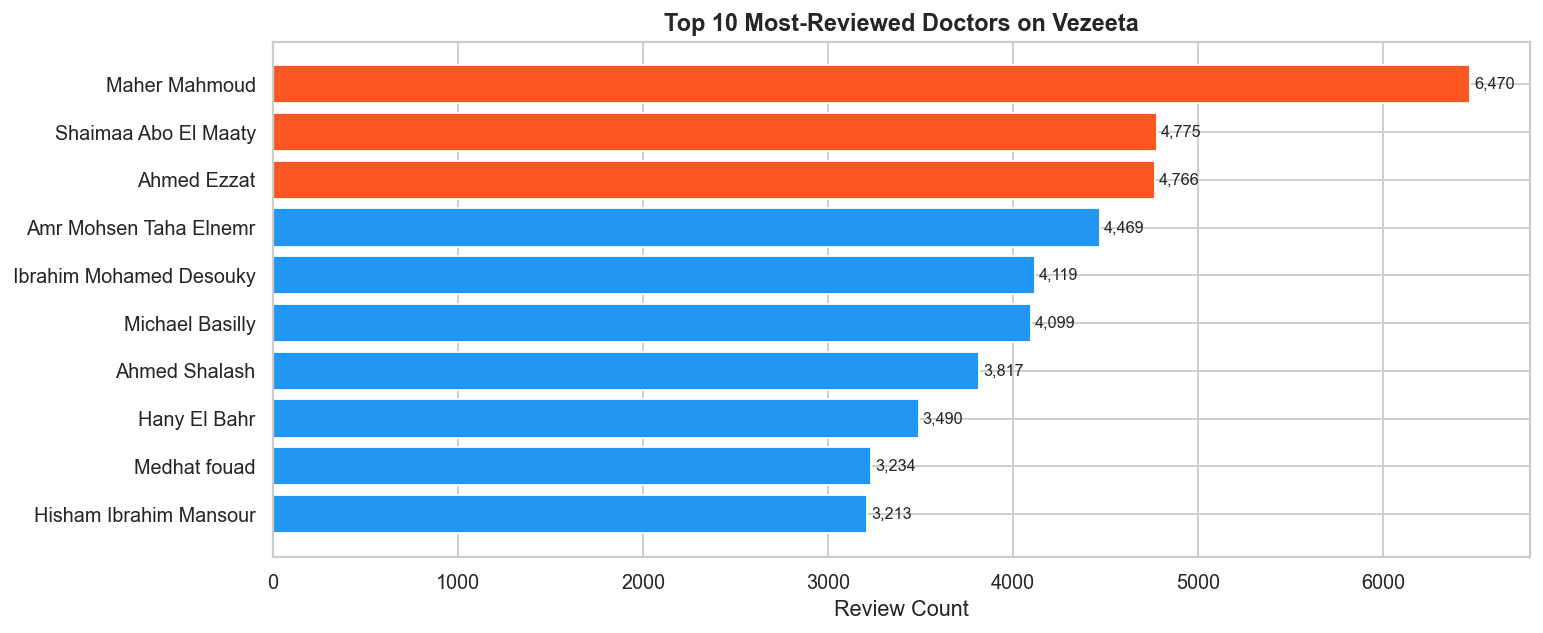


📋 Top 10 Detail:
                   name            Speciality               address  fee  reviews_count  waiting_time_min
          Maher Mahmoud           Dermatology       El-Sheikh Zayed 1300           6470              40.0
   Shaimaa Abo El Maaty           Dermatology             Nasr City  500           4775              60.0
            Ahmed Ezzat Chest and Respiratory             Nasr City  600           4766              21.0
 Amr Mohsen Taha Elnemr                   ENT             Nasr City  450           4469              20.0
Ibrahim Mohamed Desouky           Orthopedics              El-Rehab  600           4119              19.0
        Michael Basilly           Dermatology             Nasr City  550           4099              10.0
          Ahmed Shalash         Ophthalmology              El-Maadi  600           3817              20.0
           Hany El Bahr               Urology Dokki And Mohandessin  600           3490              24.0
           Medhat fouad Ches

In [16]:
## ── 4B. Top 10 Most-Reviewed Doctors

top10_docs = df.nlargest(10, 'reviews_count')[['name','Speciality','address','fee','reviews_count','waiting_time_min']]

fig, ax = plt.subplots(figsize=(12, 5))
colors_t10 = [ACCENT2 if i < 3 else ACCENT for i in range(10)]
bars = ax.barh(top10_docs['name'][::-1], top10_docs['reviews_count'][::-1], color=colors_t10[::-1])
for bar in bars:
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():,}", va='center', fontsize=9)
ax.set_title('Top 10 Most-Reviewed Doctors on Vezeeta', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Count')
plt.tight_layout()
plt.show()

print('\n📋 Top 10 Detail:')
print(top10_docs.to_string(index=False))

In [17]:
## ── 4C. Fee vs. Reviews Scatter (log scale)

scatter_df = df[df['reviews_count'] > 0].copy()

fig = px.scatter(
    scatter_df.sample(min(3000, len(scatter_df)), random_state=42),
    x='fee', y='reviews_count',
    color='Speciality',
    hover_data=['name','address'],
    log_y=True,
    opacity=0.55,
    title='Fee vs. Reviews Count (log scale) — Sample of 3,000 Doctors',
    labels={'fee':'Fee (EGP)', 'reviews_count':'Reviews Count (log)'},
    height=520
)
fig.update_traces(marker_size=5)
fig.show()

corr = df[df['reviews_count']>0][['fee','reviews_count']].corr().iloc[0,1]
print(f'\n📈 Pearson correlation (fee ↔ reviews): {corr:.3f}')
print('   → Weak correlation: high fee does NOT guarantee more reviews.')


📈 Pearson correlation (fee ↔ reviews): 0.028
   → Weak correlation: high fee does NOT guarantee more reviews.


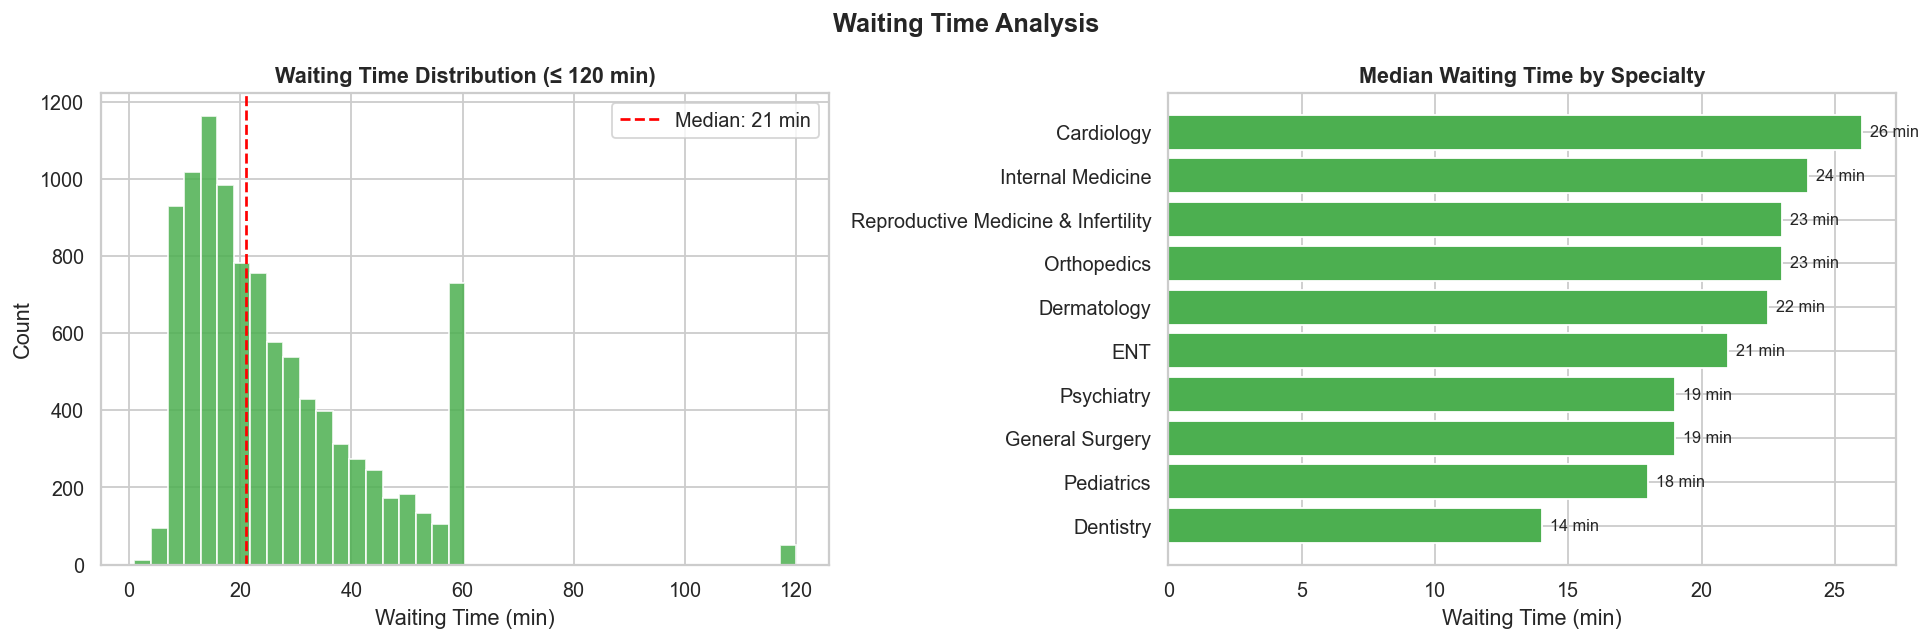


⏱️  Median waiting time (valid records): 21 min
   Doctors with waiting data: 9,902 / 17,119 (57.8%)


In [18]:
## ── 4D. Waiting Time Analysis

wt_df = df[df['waiting_time_min'].notna() & (df['waiting_time_min'] <= 120)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(wt_df['waiting_time_min'], bins=40, color=ACCENT3, edgecolor='white', alpha=0.85)
axes[0].axvline(wt_df['waiting_time_min'].median(), color='red', linestyle='--',
                label=f"Median: {wt_df['waiting_time_min'].median():.0f} min")
axes[0].set_title('Waiting Time Distribution (≤ 120 min)', fontweight='bold')
axes[0].set_xlabel('Waiting Time (min)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Waiting time by specialty (top 10)
top10_specs = df['Speciality'].value_counts().head(10).index
wt_spec = (
    wt_df[wt_df['Speciality'].isin(top10_specs)]
    .groupby('Speciality')['waiting_time_min']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
bars = axes[1].barh(wt_spec['Speciality'][::-1], wt_spec['waiting_time_min'][::-1],
                    color=ACCENT3)
for bar in bars:
    axes[1].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f"{bar.get_width():.0f} min", va='center', fontsize=9)
axes[1].set_title('Median Waiting Time by Specialty', fontweight='bold')
axes[1].set_xlabel('Waiting Time (min)')

plt.suptitle('Waiting Time Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n⏱️  Median waiting time (valid records): {wt_df['waiting_time_min'].median():.0f} min")
print(f"   Doctors with waiting data: {len(wt_df):,} / {len(df):,} ({len(wt_df)/len(df)*100:.1f}%)")